# Notebook 1 — Monant full_data · Descriptive Analysis
## claims.csv (4 classes): false, almost false, almost true, true

**Project:** A Multi-Source Benchmark for CVD Health Misinformation Detection  
**Dataset:** `full_data/claims.csv`  
**Goal:** reproduce NB1-style descriptive analysis directly on `full_data`, and export a clean file for NB2.

---
## Section 1 — Installation & Imports

In [1]:


from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Imports OK')

Imports OK


---
## Section 2 — Data Loading, Thematic Filtering, and 4-Class Labeling
Filtrage thématique: maladies cardiovasculaires + diabète (et termes associés).

In [2]:
import re
import unicodedata

claims_path = Path('full_data/claims.csv')
if not claims_path.exists():
    raise FileNotFoundError(f'File not found: {claims_path}')

claims_raw = pd.read_csv(claims_path, low_memory=False)

# Mapping aligned with NB2
rating_aliases = {
    'false': 'false',
    'mostly-false': 'almost false',
    'almost false': 'almost false',
    'mostly true': 'almost true',
    'mostly-true': 'almost true',
    'almost true': 'almost true',
    'true': 'true',
}
class_order = ['false', 'almost false', 'almost true', 'true']
label_to_id = {c: i for i, c in enumerate(class_order)}

# Thematic keywords: cardio + diabetes (FR + EN)
health_keywords = [
    # Cardiovascular diseases
    "cardiovascular disease",
    "heart disease",
    "coronary artery disease",
    "ischemic heart disease",
    "myocardial infarction",
    "heart attack",
    "stroke",
    "ischemic stroke",
    "hypertension",
    "high blood pressure",
    "heart failure",
    "arrhythmia",

    # Cardiovascular symptoms
    "chest pain",
    "angina",
    "shortness of breath",
    "dyspnea",
    "palpitations",
    "fatigue",
    "dizziness",
    "syncope",
    "edema",

    # Cardiovascular risk factors
    "smoking",
    "tobacco use",
    "obesity",
    "BMI",
    "high cholesterol",
    "LDL",
    "HDL",
    "diabetes",
    "sedentary lifestyle",
    "family history",
    "age",

    # Cardiovascular treatments
    "statins",
    "beta-blockers",
    "antihypertensive drugs",
    "aspirin therapy",
    "angioplasty",
    "stent",
    "bypass surgery",

    # Cardiovascular tests
    "ECG",
    "electrocardiogram",
    "blood pressure",
    "cholesterol levels",
    "troponin",
    "echocardiogram",

    # Diabetes types
    "type 1 diabetes",
    "type 2 diabetes",
    "gestational diabetes",
    "prediabetes",

    # Diabetes symptoms
    "frequent urination",
    "polyuria",
    "excessive thirst",
    "polydipsia",
    "fatigue",
    "weight loss",
    "blurred vision",
    "slow wound healing",

    # Diabetes treatments
    "insulin",
    "metformin",
    "glucose-lowering drugs",
    "GLP-1 agonists",
    "lifestyle intervention",
    "diet control",
    "ALA",

    # Diabetes biomarkers
    "blood glucose",
    "fasting glucose",
    "HbA1c",
    "insulin level",
    "glucose tolerance test",

    # Diabetes complications
    "neuropathy",
    "nephropathy",
    "retinopathy",
    "cardiovascular disease",
    "diabetic foot ulcer",

    # General medical terms
    "risk factor",
    "prevalence",
    "incidence",
    "mortality",
    "clinical trial",
    "diagnosis",
    "treatment outcome",
    "patient",
    "hospital",
    "clinical study",
    "randomized controlled trial",
    "medical record",
    "electronic health records",
    "clinical notes",
    "medical report"
]


def normalize_text(x):
    x = '' if pd.isna(x) else str(x)
    x = x.lower()
    x = unicodedata.normalize('NFD', x)
    x = ''.join(ch for ch in x if unicodedata.category(ch) != 'Mn')
    x = re.sub(r'\s+', ' ', x).strip()
    return x


keywords_norm = [normalize_text(k) for k in health_keywords]

# Build searchable text and keep only thematic claims
claims_raw['_search_text'] = (
    claims_raw['name'].fillna('').astype(str) + ' ' +
    claims_raw['statement'].fillna('').astype(str) + ' ' +
    claims_raw['description'].fillna('').astype(str) + ' ' +
    claims_raw['category'].fillna('').astype(str)
)
claims_raw['_search_norm'] = claims_raw['_search_text'].map(normalize_text)

pattern = '|'.join(re.escape(k) for k in sorted(set(keywords_norm), key=len, reverse=True))
mask_theme = claims_raw['_search_norm'].str.contains(pattern, regex=True, na=False)
claims_thematic = claims_raw[mask_theme].copy()

# Save filtered raw CSV for downstream notebook NB2
filtered_raw_path = Path('full_data/claims_cardio_diabete_filtered.csv')
claims_thematic.drop(columns=['_search_text', '_search_norm']).to_csv(filtered_raw_path, index=False)

# 4-class labeling on filtered thematic subset
df_claims = claims_thematic.copy()
df_claims['rating_norm'] = df_claims['rating'].astype(str).str.strip().str.lower()
df_claims['label_name'] = df_claims['rating_norm'].map(rating_aliases)
df_claims = df_claims[df_claims['label_name'].isin(class_order)].copy()
df_claims['label'] = df_claims['label_name'].map(label_to_id).astype(int)

df_claims['text'] = (
    df_claims['name'].fillna('').astype(str) + ' ' +
    df_claims['statement'].fillna('').astype(str) + ' ' +
    df_claims['description'].fillna('').astype(str)
)
df_claims['text'] = df_claims['text'].str.replace(r'\s+', ' ', regex=True).str.strip()
df_claims = df_claims[df_claims['text'].astype(bool)].copy()
df_claims['text_len'] = df_claims['text'].str.len()

print(f'Raw rows (claims.csv): {len(claims_raw)}')
print(f'Thematic rows (cardio+diabetes): {len(claims_thematic)}')
print(f'Filtered raw CSV saved: {filtered_raw_path}')
print(f'Filtered rows with 4-class labels: {len(df_claims)}')
print(df_claims['label_name'].value_counts().reindex(class_order, fill_value=0).to_string())

Raw rows (claims.csv): 3423
Thematic rows (cardio+diabetes): 1278
Filtered raw CSV saved: full_data/claims_cardio_diabete_filtered.csv
Filtered rows with 4-class labels: 732
label_name
false           504
almost false     60
almost true      31
true            137


---
## Section 4 — Descriptive Visualizations

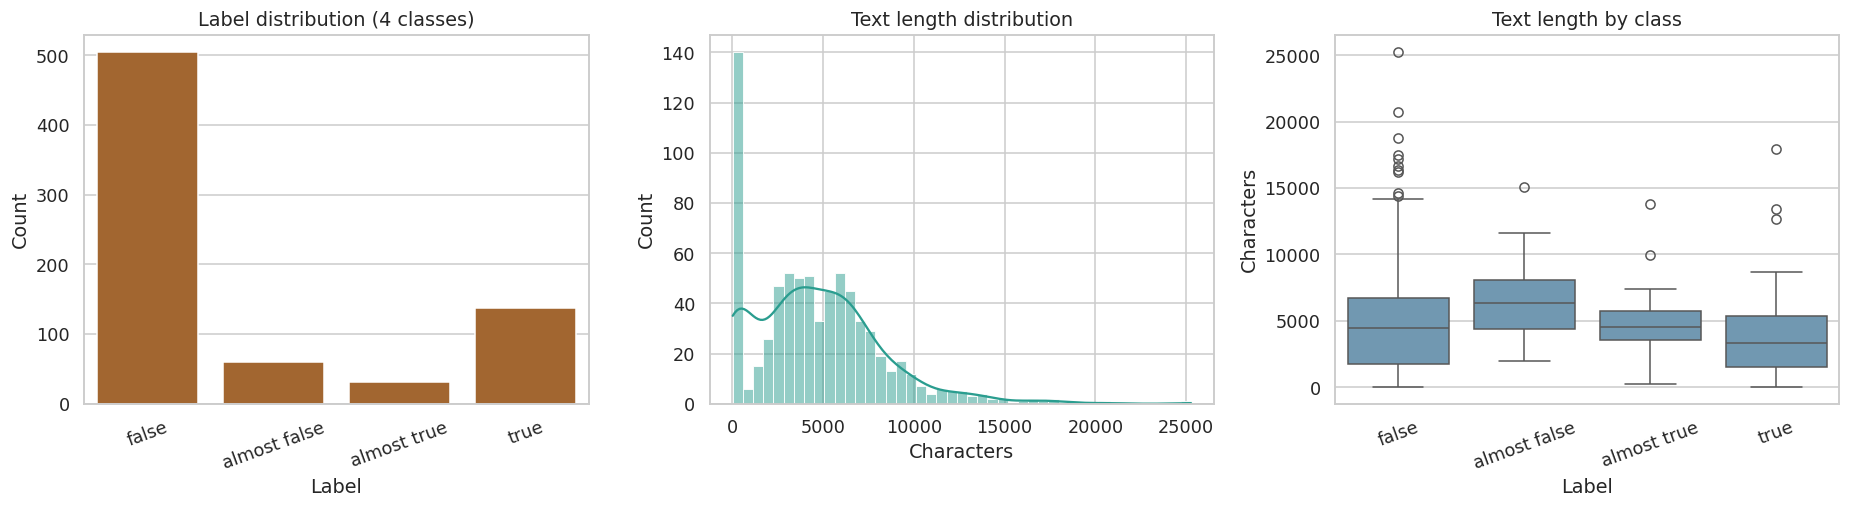

Saved: fig_nb1_claims_4classes_overview.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

sns.countplot(data=df_claims, x='label_name', order=class_order, ax=axes[0], color='#b5651d')
axes[0].set_title('Label distribution (4 classes)')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)

sns.histplot(df_claims['text_len'], bins=45, kde=True, ax=axes[1], color='#2a9d8f')
axes[1].set_title('Text length distribution')
axes[1].set_xlabel('Characters')
axes[1].set_ylabel('Count')

sns.boxplot(data=df_claims, x='label_name', y='text_len', order=class_order, ax=axes[2], color='#669bbc')
axes[2].set_title('Text length by class')
axes[2].set_xlabel('Label')
axes[2].set_ylabel('Characters')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('fig_nb1_claims_4classes_overview.png', bbox_inches='tight', dpi=130)
plt.show()
print('Saved: fig_nb1_claims_4classes_overview.png')

---
## Section 5 — Lexical Analysis (Top Terms)


Targeted cardio term frequencies:


,term,count,docs
0,heart attack,70,14
1,stroke,35,10
2,heart disease,24,18
3,hypertension,13,8
4,high blood pressure,8,7
5,myocardial infarction,3,3
6,cardiovascular disease,3,3
7,coronary artery disease,2,2
8,arrhythmia,2,2
9,heart failure,1,1



Targeted diabetes term frequencies:


,term,count,docs
0,diabetes,48,23
1,glucose,23,7
2,insulin,14,7
3,type 1 diabetes,11,2
4,type 2 diabetes,4,4
5,blood glucose,3,2
6,gestational diabetes,0,0
7,prediabetes,0,0
8,metformin,0,0
9,hba1c,0,0


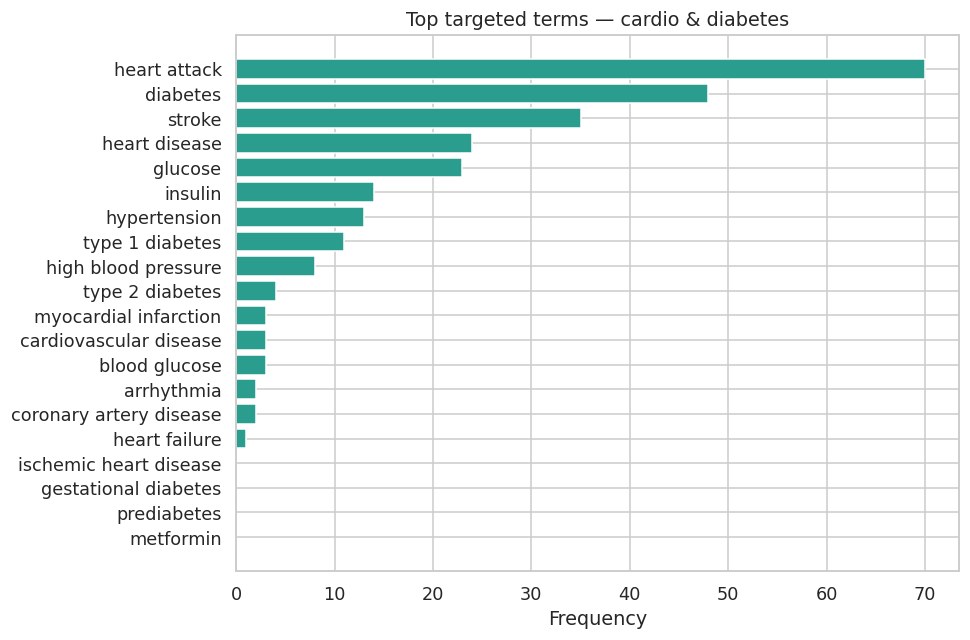

In [5]:

cardio_terms = [
    'cardiovascular disease','heart disease','coronary artery disease',
    'ischemic heart disease','myocardial infarction','heart attack','stroke',
    'hypertension','high blood pressure','heart failure','arrhythmia'
]
diabetes_terms = [
    'diabetes','type 1 diabetes','type 2 diabetes','gestational diabetes','prediabetes',
    'insulin','metformin','glucose','blood glucose','hba1c','hyperglycemia','hypoglycemia'
]

def count_terms(df, text_col, terms):
    text = df[text_col].fillna('').astype(str).str.lower()
    rows = []
    for t in terms:
        patt = r'\b' + re.escape(t) + r'\b'
        cnt = int(text.str.count(patt).sum())
        docs = int(text.str.contains(patt, regex=True).sum())
        rows.append({'term': t, 'count': cnt, 'docs': docs})
    return pd.DataFrame(rows).sort_values('count', ascending=False).reset_index(drop=True)

print('\nTargeted cardio term frequencies:')
cardio_stats = count_terms(df_claims, 'text', cardio_terms)
display(cardio_stats)

print('\nTargeted diabetes term frequencies:')
diabetes_stats = count_terms(df_claims, 'text', diabetes_terms)
display(diabetes_stats)

# Plot top targeted terms (combined)
combined = pd.concat([cardio_stats.assign(category='cardio'), diabetes_stats.assign(category='diabetes')], ignore_index=True)
top_combined = combined.sort_values('count', ascending=False).head(20)
plt.figure(figsize=(9, 6))
plt.barh(top_combined['term'][::-1], top_combined['count'][::-1], color='#2a9d8f')
plt.title('Top targeted terms — cardio & diabetes')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()


---
## Section 6 — Export Files for NB2

In [18]:
baseline_ready = df_claims[['id', 'text', 'label_name', 'label', 'rating_norm', 'category']].copy()
baseline_ready.to_csv('full_data_claims_cardio_diabete_baseline_ready_4classes.csv', index=False)

class_stats = (
    df_claims['label_name']
    .value_counts()
    .reindex(class_order, fill_value=0)
    .rename_axis('label_name')
    .reset_index(name='count')
)
class_stats['pct'] = (100 * class_stats['count'] / class_stats['count'].sum()).round(2)
class_stats.to_csv('full_data_claims_cardio_diabete_4classes_stats.csv', index=False)

print('Saved: full_data_claims_cardio_diabete_baseline_ready_4classes.csv')
print(f'Rows: {len(baseline_ready)}')
print('\nSaved: full_data_claims_cardio_diabete_4classes_stats.csv')
print(class_stats.to_string(index=False))

Saved: full_data_claims_cardio_diabete_baseline_ready_4classes.csv
Rows: 732

Saved: full_data_claims_cardio_diabete_4classes_stats.csv
  label_name  count   pct
       false    504 68.85
almost false     60  8.20
 almost true     31  4.23
        true    137 18.72
